In [ ]:
pip install matplotlib numpy opencv-python scipy

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 2.3 MB/s  0:00:04 eta 0:00:010m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.0 MB/s  0:00:01 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import cv2


In [7]:
img = '/Users/roman/VScode/images.jpeg'
img = cv2.imread(img)
img = np.array(img)
print(img.shape)
print(img.dtype)
print(img.size)
print(img.ndim)

(225, 225, 3)
uint8
151875
3


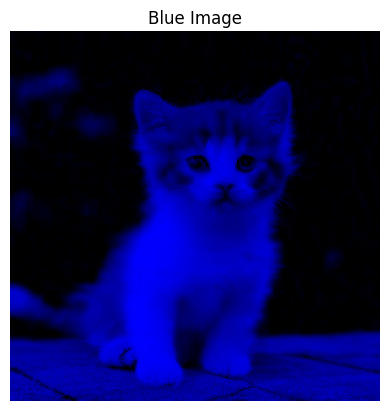

In [8]:
import matplotlib.pyplot as plt

blue_chanel = img[:,:,0]
blue_img = np.zeros_like(img)
blue_img[:,:,0] = blue_chanel
blue_img_rgb = cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB)
plt.imshow(blue_img_rgb)
plt.title('Blue Image')
plt.axis('off')
plt.show()

In [14]:
from scipy.ndimage import gaussian_filter

img_with_gaussian_noise = gaussian_filter(img.astype(float), sigma=2)
img_with_gaussian_noise = np.clip(img_with_gaussian_noise, 0, 255).astype(np.uint8)

height, width = img_with_gaussian_noise.shape[:2]
img_resized = cv2.resize(img_with_gaussian_noise, (width//2, height//2))

h, w = img_resized.shape[:2]
crop_x, crop_y = w // 5, h // 5
crop_w, crop_h = w * 3 // 5, h * 3 // 5
img_cropped = img_resized[crop_y:crop_y+crop_h, crop_x:crop_x+crop_w]

img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)

img_gray = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2GRAY)
_, thresh_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morph = cv2.morphologyEx(thresh_binary, cv2.MORPH_OPEN, kernel)
morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


Площадь объекта: 3061.50 пикселей
Центр объекта: (34, 34)


Площадь объекта: 3061.50 пикселей
Центр объекта: (34, 34)


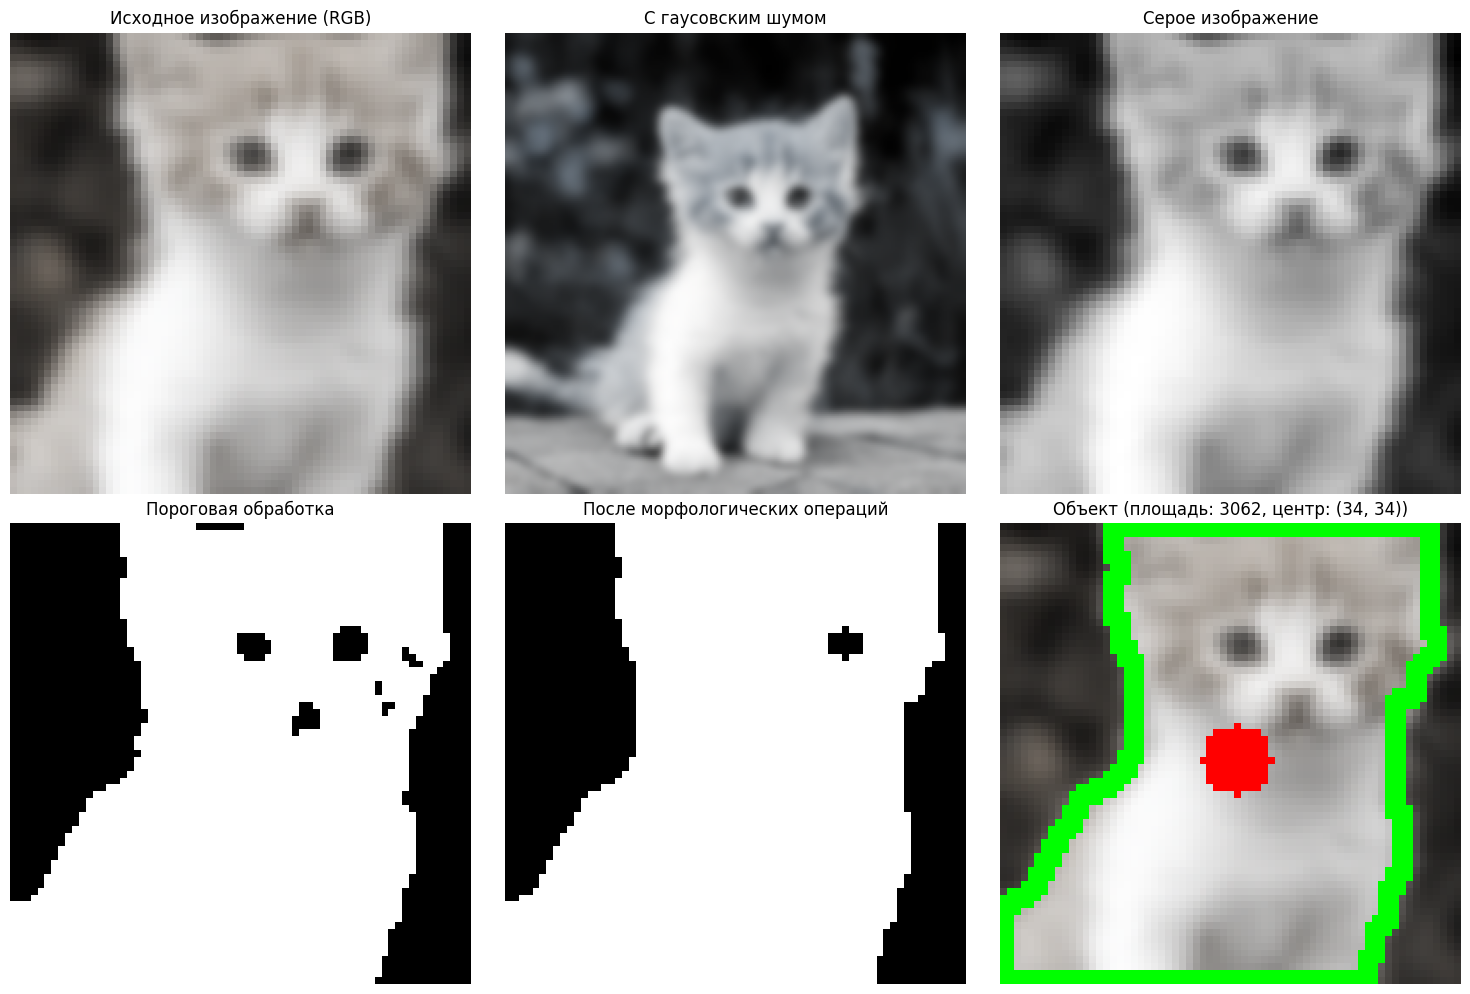

In [26]:
#сгенерированно 
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    M = cv2.moments(largest_contour)
    
    if M['m00'] > 0:
        center_x = int(M['m10'] / M['m00'])
        center_y = int(M['m01'] / M['m00'])
    else:
        center_x, center_y = 0, 0
    
    print(f"Площадь объекта: {area:.2f} пикселей")
    print(f"Центр объекта: ({center_x}, {center_y})")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Исходное изображение (RGB)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_with_gaussian_noise)
    axes[0, 1].set_title('С гаусовским шумом')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_gray, cmap='gray')
    axes[0, 2].set_title('Серое изображение')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(thresh_binary, cmap='gray')
    axes[1, 0].set_title('Пороговая обработка')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(morph, cmap='gray')
    axes[1, 1].set_title('После морфологических операций')
    axes[1, 1].axis('off')
    
    result = img_rgb.copy()
    cv2.drawContours(result, [largest_contour], 0, (0, 255, 0), 2)
    cv2.circle(result, (center_x, center_y), 5, (255, 0, 0), -1)
    axes[1, 2].imshow(result)
    axes[1, 2].set_title(f'Объект (площадь: {area:.0f}, центр: ({center_x}, {center_y}))')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Контуры не найдены")

(259, 194, 3)
uint8
150738
3


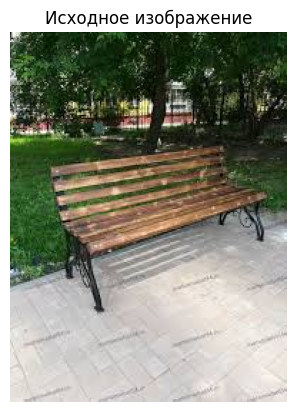

In [12]:
img_1 = cv2.imread('/Users/roman/VScode/images_1.jpeg')
img_1 = np.array(img_1)
print(img_1.shape)
print(img_1.dtype)
print(img_1.size)
print(img_1.ndim)

img_1_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
plt.imshow(img_1_rgb)
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

In [63]:
img_1_cleaned = cv2.medianBlur(img_1, 5)

h1, w1 = img_1_cleaned.shape[:2]
img_1_resized = cv2.resize(img_1_cleaned, (w1, h1))

h, w = img_1_resized.shape[:2]
crop_x, crop_y = w // 5, h // 5
crop_w, crop_h = w * 3 // 5, h * 3 // 5
img_1_cropped = img_1_resized[crop_y:crop_y+crop_h, crop_x:crop_x+crop_w]

img_1_rgb = cv2.cvtColor(img_1_cropped, cv2.COLOR_BGR2RGB)

img_1_gray = cv2.cvtColor(img_1_cropped, cv2.COLOR_BGR2GRAY)
img_1_eq = cv2.equalizeHist(img_1_gray)

_, thresh_1 = cv2.threshold(img_1_eq, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

step_erode_1 = cv2.erode(thresh_1, kernel, iterations=1)
step_dilate_after_erode = cv2.dilate(step_erode_1, kernel, iterations=1)

step_dilate_1 = cv2.dilate(thresh_1, kernel, iterations=1)
step_erode_after_dilate = cv2.erode(step_dilate_1, kernel, iterations=1)

opened = step_dilate_after_erode
closed = step_erode_after_dilate

contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = None
area = 0
center_x, center_y = 0, 0

if contours:
    for contour in contours:
        contour_area = cv2.contourArea(contour)
        if contour_area > 500:
            if contour_area > area:
                largest_contour = contour
                area = contour_area
    
    if largest_contour is not None:
        M = cv2.moments(largest_contour)
        if M['m00'] > 0:
            center_x = int(M['m10'] / M['m00'])
            center_y = int(M['m01'] / M['m00'])


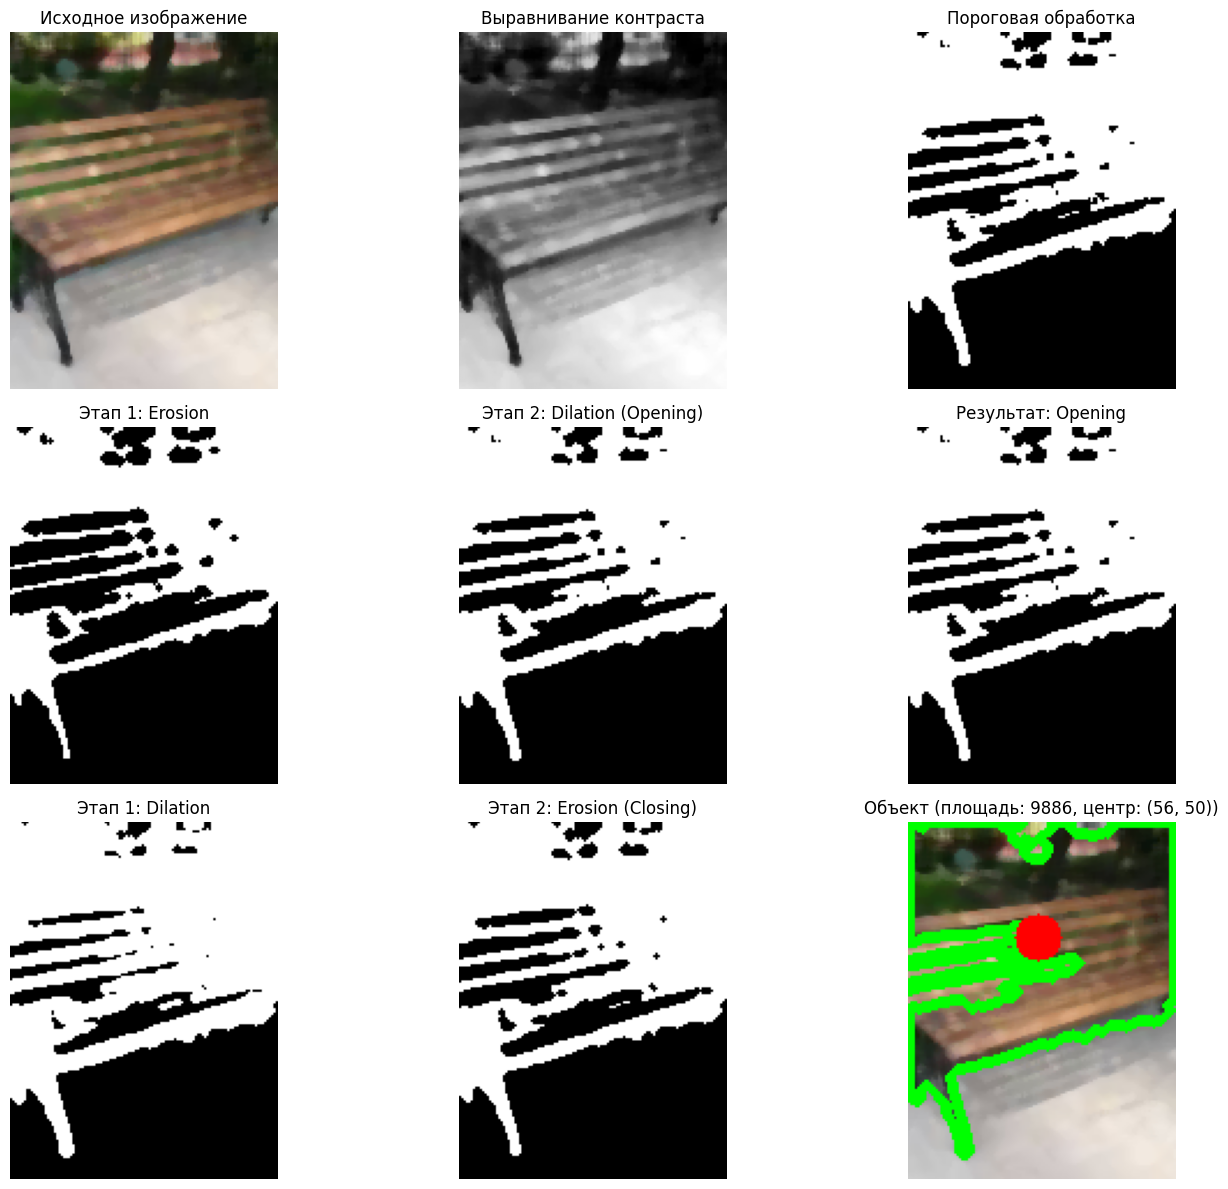

Площадь объекта: 9885.50 пикселей
Центр объекта: (56, 50)


In [64]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes[0, 0].imshow(img_1_rgb)
axes[0, 0].set_title('Исходное изображение')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_1_eq, cmap='gray')
axes[0, 1].set_title('Выравнивание контраста')
axes[0, 1].axis('off')

axes[0, 2].imshow(thresh_1, cmap='gray')
axes[0, 2].set_title('Пороговая обработка')
axes[0, 2].axis('off')

axes[1, 0].imshow(step_erode_1, cmap='gray')
axes[1, 0].set_title('Этап 1: Erosion')
axes[1, 0].axis('off')

axes[1, 1].imshow(step_dilate_after_erode, cmap='gray')
axes[1, 1].set_title('Этап 2: Dilation (Opening)')
axes[1, 1].axis('off')

axes[1, 2].imshow(opened, cmap='gray')
axes[1, 2].set_title('Результат: Opening')
axes[1, 2].axis('off')

axes[2, 0].imshow(step_dilate_1, cmap='gray')
axes[2, 0].set_title('Этап 1: Dilation')
axes[2, 0].axis('off')

axes[2, 1].imshow(step_erode_after_dilate, cmap='gray')
axes[2, 1].set_title('Этап 2: Erosion (Closing)')
axes[2, 1].axis('off')

result = img_1_rgb.copy()
if largest_contour is not None:
    cv2.drawContours(result, [largest_contour], 0, (0, 255, 0), 3)
    cv2.circle(result, (center_x, center_y), 10, (255, 0, 0), -1)

axes[2, 2].imshow(result)
axes[2, 2].set_title(f'Объект (площадь: {area:.0f}, центр: ({center_x}, {center_y}))')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Площадь объекта: {area:.2f} пикселей")
print(f"Центр объекта: ({center_x}, {center_y})")
